In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer.windfield import WindField
from Tracer.tracer import solver, initial_velocity, fetch_wind_data

## Investigating the difference between log and uniform wind

### Simulator

In [14]:
# Input
shot_speed = 76.44384
shot_angle = 10.4	
shot_spin = 2545   	
P0 = [0,0,0]
U_ref = 10
z0 = 0.03
direction = 0
nx = 300
ny = 500
nz = 100
dt = 0.01

# Simulation
def run_simulation(direction=direction, z0=z0, U_ref=U_ref):
    
    # Log wind
    log_wind = WindField(nx=nx, ny=ny, nz=nz, direction=direction, profile='log', z0=z0, U_ref=U_ref)
    log_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    log_W0 = np.array([0, -shot_spin, 0])
    log_t, log_p, log_v, log_w = solver(P0, log_V0, log_W0, log_wind, dt=dt)

    # calculating uniform
    uni_wind = WindField(nx=nx, ny=ny, nz=nz, direction=direction, profile='uniform', z0=z0, U_ref=U_ref)
    uni_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    uni_W0 = np.array([0, -shot_spin, 0])
    uni_t, uni_p, uni_v, uni_w = solver(P0, uni_V0, uni_W0, uni_wind, dt=dt)

    return log_p, uni_p

### Changing wind direction

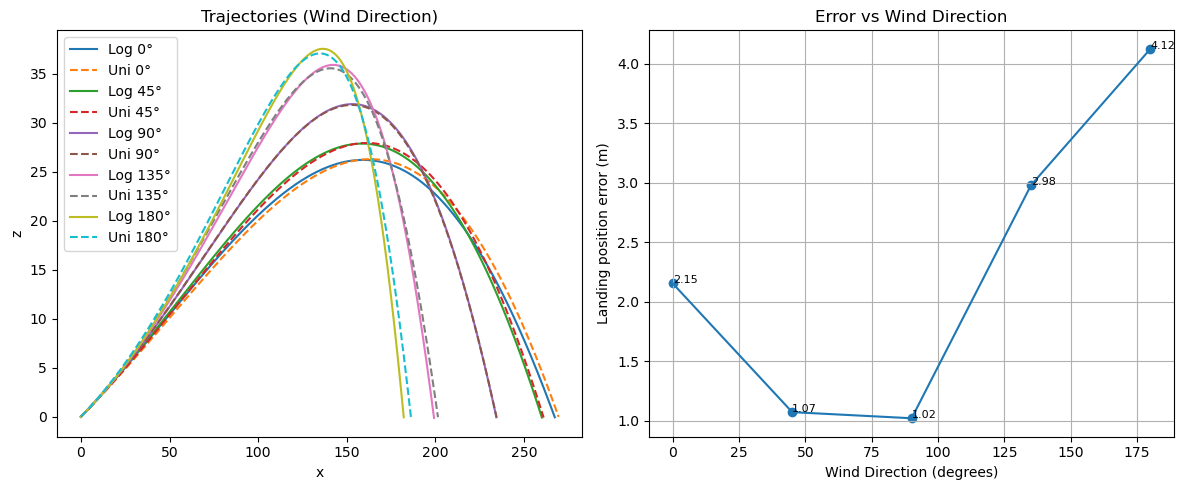

In [15]:
# Wind

directions = [0, 45, 90, 135, 180]

dir_results = {}
dir_errors = []

for d in directions:
    log_p, uni_p = run_simulation(direction=d, z0=0.03, U_ref=U_ref)
    dir_results[d] = (log_p, uni_p)

    error = np.sqrt((log_p[-1, 0] - uni_p[-1, 0])**2 + (log_p[-1, 1] - uni_p[-1, 1])**2)
    dir_errors.append(error)

# Plot left

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for d in directions:
    log_p, uni_p = dir_results[d]

    ax1.plot(log_p[:, 0], log_p[:, 2], label=f'Log {d}°')
    ax1.plot(uni_p[:, 0], uni_p[:, 2], '--', label=f'Uni {d}°')

ax1.set_xlabel("x")
ax1.set_ylabel("z")
ax1.set_title("Trajectories (Wind Direction)")
ax1.legend()

# Plot right

ax2.scatter(directions, dir_errors)
ax2.plot(directions, dir_errors)

for x, y in zip(directions, dir_errors):
    ax2.text(x, y, f"{y:.2f}", fontsize=8)

ax2.set_xlabel("Wind Direction (degrees)")
ax2.set_ylabel("Landing position error (m)")
ax2.set_title("Error vs Wind Direction")
ax2.grid()

plt.tight_layout()
plt.show()

### Changing roughness

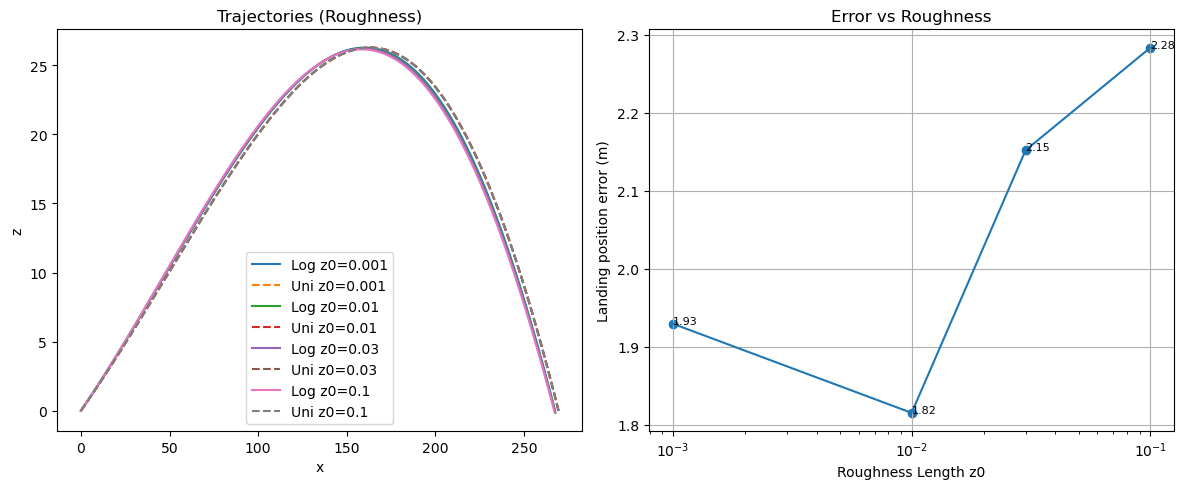

In [16]:
# Roughness

roughness_values = [0.001, 0.01, 0.03, 0.1]

rough_results = {}
rough_errors = []

for z in roughness_values:
    log_p, uni_p = run_simulation(direction=0, z0=z, U_ref=U_ref)
    rough_results[z] = (log_p, uni_p)

    error = np.sqrt((log_p[-1, 0] - uni_p[-1, 0])**2 + (log_p[-1, 1] - uni_p[-1, 1])**2)
             
    rough_errors.append(error)

# Plot left
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for z in roughness_values:
    log_p, uni_p = rough_results[z]

    ax1.plot(log_p[:, 0], log_p[:, 2], label=f'Log z0={z}')
    ax1.plot(uni_p[:, 0], uni_p[:, 2], '--', label=f'Uni z0={z}')

ax1.set_xlabel("x")
ax1.set_ylabel("z")
ax1.set_title("Trajectories (Roughness)")
ax1.legend()

# Plot right

ax2.scatter(roughness_values, rough_errors)
ax2.plot(roughness_values, rough_errors)

for x, y in zip(roughness_values, rough_errors):
    ax2.text(x, y, f"{y:.2f}", fontsize=8)

ax2.set_xscale("log")
ax2.set_xlabel("Roughness Length z0")
ax2.set_ylabel("Landing position error (m)")
ax2.set_title("Error vs Roughness")
ax2.grid()

plt.tight_layout()
plt.show()

### Changing wind direction and shot U_ref

In [29]:
# Wind

U_refs = [0,1,2,3,4,5,6,7,8,9,10]
U_ref_errors = []

directions = [0, 45, 90, 135, 180]
dir_results = {}

for u in U_refs:
    U_ref = U_refs[u]
    dir_errors = []

    for d in directions:

        log_p, uni_p = run_simulation(direction=d, z0=0.03, U_ref=U_ref)
        dir_results[d] = (log_p, uni_p)

        error = np.sqrt((log_p[-1, 0] - uni_p[-1, 0])**2 + (log_p[-1, 1] - uni_p[-1, 1])**2)
        dir_errors.append(error)
    
    U_ref_errors.append(dir_errors)

print(U_ref_errors)

[[0.0, 0.0, 0.0, 0.0, 0.0], [0.03734406341874319, 0.19937216701767654, 0.07110039603582102, 0.06343590390606094, 0.1078599236531943], [0.009895509364497457, 0.13667797975060872, 0.1441789387170166, 0.16452018887293837, 0.28116342937656214], [0.08655602356478198, 0.054581953802766765, 0.22158448856756788, 0.31450825567994734, 0.5316045993574221], [0.24381045857668937, 0.14932683983214678, 0.3041887578039126, 0.5209707352159734, 0.8515682191147107], [0.4704910693405111, 0.07808201879251542, 0.4203853826003704, 0.7808147296010902, 1.0741969756858794], [1.0393492575665846, 0.30942701038978315, 0.5055904136055965, 1.2044483111054531, 1.5507660444736757], [1.1027461760231176, 0.592285137525062, 0.6027915769127462, 1.5805153027593497, 1.9621804267283665], [1.5026051706508383, 0.6234999392632902, 0.7160145711176026, 1.99848637236894, 2.6074245066523645], [1.961719662741757, 0.9695367063598658, 0.8841817496879085, 2.421926560080198, 3.3151663037646983], [2.1519104820656025, 1.0706234977324147, 

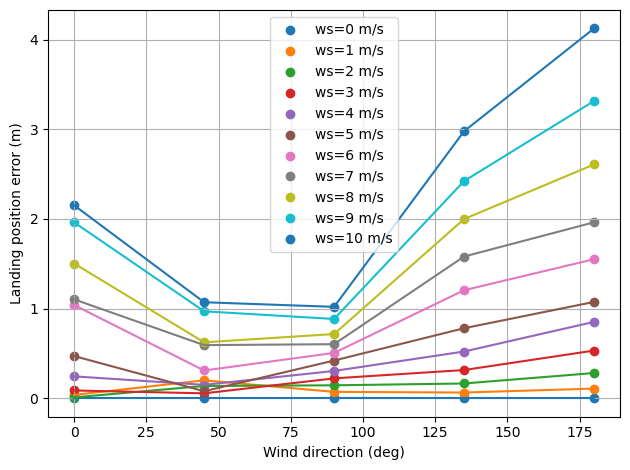

In [32]:
for i in range(len(U_refs)):
    plt.scatter(directions,U_ref_errors[i],label=f'ws={U_refs[i]} m/s')
    plt.plot(directions,U_ref_errors[i])

plt.xlabel('Wind direction (deg)')
plt.ylabel('Landing position error (m)')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()